In [22]:
import numpy as np
import matplotlib.pyplot as plt
from hdg_postprocess.formats import load_from_file
import scipy.io

# First, solution without additional cooling and without impurity radiation

In [23]:
solpath = './data/solutions/power_balance_boundary_checks/'
solname = 'solution_west_no_heating_no_cooling_factor'

In [24]:
sol=load_from_file.load_HDG_solution_from_file(solpath,solname)

## typical overview

Initializing physical solution first
Comibining first simple solution full
Comibining first solution full


/home/ikudashev/Documents/Github/HDG_postprocess/hdg_postprocess/HDG_mesh.py:382: UserWarning: The following kwargs were not used by contour: 'triangles', 'extendrect'
  im = ax.tricontourf(self.vertices_glob[:,0], self.vertices_glob[:,1], np.log10(data),levels=n_levels
/home/ikudashev/Documents/Github/HDG_postprocess/hdg_postprocess/HDG_mesh.py:395: UserWarning: The following kwargs were not used by contour: 'triangles', 'extendrect'
  im = ax.tricontourf(self.vertices_glob[:,0], self.vertices_glob[:,1], data,levels=n_levels


(<Figure size 1080x1620 with 11 Axes>,
 array([[<Axes: title={'center': 'n [m$^{-3}$]'}, xlabel='R [m]', ylabel='Z [m]'>,
         <Axes: title={'center': '$n_n$ [m$^{-3}$]'}, xlabel='R [m]', ylabel='Z [m]'>],
        [<Axes: title={'center': '$T_i [eV]$'}, xlabel='R [m]', ylabel='Z [m]'>,
         <Axes: title={'center': '$T_e [eV] $'}, xlabel='R [m]', ylabel='Z [m]'>],
        [<Axes: title={'center': 'M'}, xlabel='R [m]', ylabel='Z [m]'>,
         <Axes: >]], dtype=object),
 array([[ 1.00978545e+14,  5.57880389e+16,  7.48423091e-01,
          1.63946400e-01, -1.39415897e-02],
        [ 8.39894789e+13,  5.57879306e+16,  6.57517351e-01,
          1.43570316e-01,  3.38094147e-04],
        [ 1.02868383e+14,  5.57877515e+16,  7.62727933e-01,
          1.64476916e-01,  2.39892401e-03],
        ...,
        [ 6.35343000e+14,  9.47339264e+15,  6.26322802e-01,
          2.42076144e-01, -7.05540649e-02],
        [ 6.36252051e+14,  9.47339407e+15,  6.35986247e-01,
          2.42175306e-01, -7.

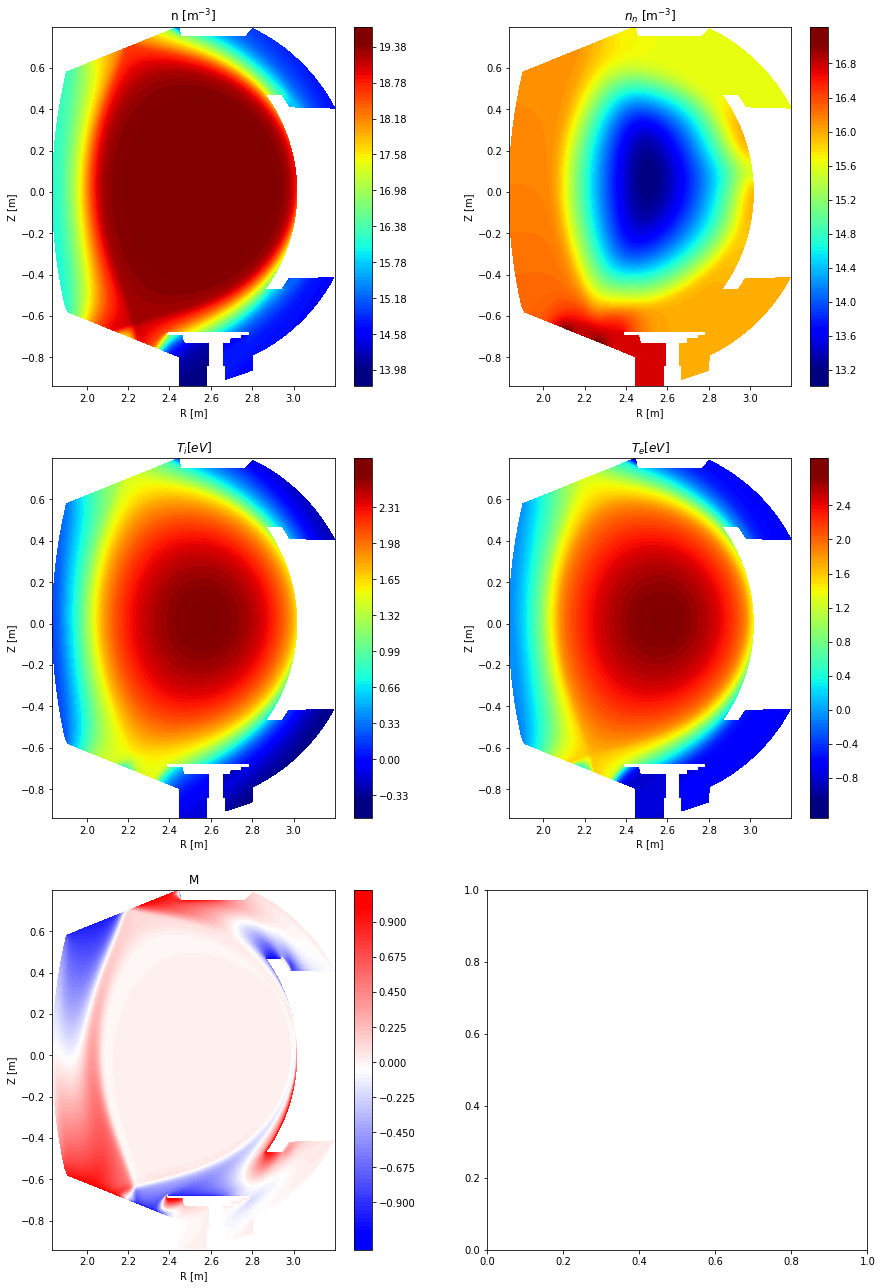

In [25]:
sol.plot.physical_overview()

In [26]:
ref_elem = scipy.io.loadmat('./data/reference_elements/reference_triangle_P8.mat')
name = 'refEl'
ref_dic = {}
ref_dic['IPcoordinates'] = ref_elem[name][0,0][0]  # gauss 2D points coordinates
ref_dic['IPweights'] = ref_elem[name][0,0][1][:,0]  # gauss points 2D integration weights
ref_dic['N'] = ref_elem[name][0,0][2]  # Shape functions 2D from nodal elements to Gauss points
ref_dic['Nxi'] = ref_elem[name][0,0][3]  # Derivative by xi shape functions 2D from nodal elements to Gauss points
ref_dic['Neta'] = ref_elem[name][0,0][4]  # Derivative by eta shape functions 2D from nodal elements to Gauss points
ref_dic['IPcoordinates1d'] = ref_elem[name][0,0][5]  # gauss 1D points coordinates
ref_dic['IPweights1d'] = ref_elem[name][0,0][6]  # gauss points 1D integration weights
ref_dic['N1d'] = ref_elem[name][0,0][7]  # Shape functions 1D from nodal elements to Gauss points
ref_dic['N1dxi'] = ref_elem[name][0,0][8]  # Derivative by xi shape functions 1D from nodal elements to Gauss points
ref_dic['faceNodes'] = ref_elem[name][0,0][9] -1 # connectivity for face elements
ref_dic['innerNodes'] = ref_elem[name][0,0][10] 
ref_dic['faceNodes1d'] = ref_elem[name][0,0][11] -1
ref_dic['NodesCoord'] = ref_elem[name][0,0][12] 
ref_dic['NodesCoord1d'] = ref_elem[name][0,0][13] 
ref_dic['degree'] = ref_elem[name][0,0][14] 
#ref_dic['elemType'] = ref_elem[name][0,0][15] 
sol.mesh.reference_element = ref_dic

In [27]:
atomic_data = './data/atomic/'

In [28]:
alpha_iz  = np.load(f'{atomic_data}/alpha_iz.npy')

iz_param = {}
iz_param['database'] = "AMJUEL 2.1.5JH"
iz_param['alpha'] = alpha_iz
iz_param['te_min'] = 0.1
iz_param['te_max'] = 2e4
iz_param['ne_min'] = 1e14
iz_param['ne_max'] = 1e22

alpha_rec = np.load(f'{atomic_data}/alpha_rec_2.1.8JH.npy')
rec_param = {}
rec_param['database'] = "AMJUEL 2.1.8JH"
rec_param['alpha'] = alpha_rec
rec_param['te_min'] = 0.1
rec_param['te_max'] = 2e4
rec_param['ne_min'] = 1e14
rec_param['ne_max'] = 1e22


alpha_cx = np.array([-1.87744894e+01,  4.51800000e-01, -3.58100000e-02,  8.00400000e-03, -6.83700000e-04])
cx_param = {}
cx_param['database'] = "OpenADAS expanded"
cx_param['alpha'] = alpha_cx
cx_param['te_min'] = 0.1
cx_param['te_max'] = 2e4

alpha_Eiz = np.load(f'{atomic_data}/alpha_energy_iz.npy')
Eiz_param = {}
Eiz_param['database'] = "AMJUEL 2.1.5JH"
Eiz_param['alpha'] = alpha_Eiz
Eiz_param['te_min'] = 0.1
Eiz_param['te_max'] = 2e4
Eiz_param['ne_min'] = 1e14
Eiz_param['ne_max'] = 1e22

alpha_Erec = np.load(f'{atomic_data}/alpha_energy_rec.npy')
Erec_param = {}
Erec_param['database'] = "AMJUEL 2.1.8JH"
Erec_param['alpha'] = alpha_Erec
Erec_param['te_min'] = 0.1
Erec_param['te_max'] = 2e4
Erec_param['ne_min'] = 1e14
Erec_param['ne_max'] = 1e22



atomic = {}
atomic['iz'] = iz_param
atomic['cx'] = cx_param
atomic['rec'] = rec_param
atomic['Eiz'] = Eiz_param
atomic['Erec'] = Erec_param




In [29]:
diff_nn_params = {}
diff_nn_params['const'] = False
diff_nn_params['dnn_soft'] = True
diff_nn_params['dnn_max'] = 2e8
diff_nn_params['dnn_min'] = 3.
diff_nn_params['dnn_w'] = 0.01
diff_nn_params['dnn_width'] = 10
diff_nn_params['ti_soft'] = True
diff_nn_params['ti_min'] = 1e-6
diff_nn_params['ti_w'] = 0.01
diff_nn_params['ti_width'] = 10

### important R_E is not saved in the solution, so you should know it from HDG_ComputeJacobian, assemblyNeutral in the end. 

### typically in latest versions it is 0, so no energy goes from neutrals to ions after ionization

### in older versions of the code it was 1

In [30]:
sol.additional_parameters.set_atomic(atomic)
sol.additional_parameters.set_neutral_diffusion(diff_nn_params, sol.parameters["adimensionalization"])
sol.parameters['physics']['R_E'] = 0. #solution from recent version


In [31]:
power_balance = sol.analysis.power_balance()

Calculating volumetric sources for power balance evaluation
Calculating ohmic source on gauss points first
Calculating on gauss points first
Calculating electron ionization sink on gauss points first
Calculating electron recombination sink on gauss points first
Calculating ionization gain on gauss points first
Calculating electron recombination gain on gauss points first
Calculating ion recombination sink on gauss points first
Calculating ion charge exchange sink on gauss points first
Calculating power losses to the wall for power balance evaluation
Calculating boundary summary first
Comibining first values on boundary
Comibining first boundary connectivity and info
(721, 9, 5)


In [32]:
for key in power_balance.keys():
    if key != 'relative_power_balance':
        print(f'{key}: {power_balance[key]:.2f} W')
    else:
        print(f'{key}: {power_balance[key]*100:.2f} %')

    

ohmic_heating: 822852.23 W
electron_sink_iz: 97612.92 W
electron_sink_rec: 385.45 W
ion_gain_iz: 0.00 W
electron_gain_rec: 73.17 W
ion_sink_rec: 1210.85 W
ion_sink_cx: 10337.12 W
electron_sink_tot: 97925.19 W
ion_sink_tot: 11547.97 W
total_loss: 109473.16 W
total_heating: 822852.23 W
ion_wall_loss: 329803.26 W
electron_wall_loss: 383575.85 W
total_wall_loss: 713379.12 W
power_balance: -0.05 W
relative_power_balance: -0.00 %


### electron_sink_iz = $\int_V n n_n<\sigma v k_b T_{loss}>_{iz}$
### electron_sink_rec = $\int_Vn^2<\sigma v k_b T_{loss}>_{rec}$
### ion_gain_iz = $\int_V n n_n<\sigma v>_{iz}R_E(3/2k_bT_i)$
### electron_sink_rec = $\int_V13.6k_bn^2<\sigma v>_{rec}$
### ion_sink_rec = $\int_V13.6k_bn^2<\sigma v>_{rec}$
### ion_sink_cx = $\int_V 1/2n_n n m_i u^2<\sigma v>_{cx}$
### electron_sink_tot = electron_sink_iz+electron_sink_rec-electron_sink_rec
### ion_sink_tot = ion_sink_cx+ion_sink_rec-ion_gain_iz
### total_loss = electron_sink_tot+ion_sink_tot
### electron_wall_loss = $\int_S \gamma_\text{e} u nk_\text{b}T_\text{e}(\textbf{b}\cdot \textbf{n})$

### ion_wall_loss = $\int_S (\gamma_\text{i} u nk_\text{b}T_\text{i}+1/2nm_iu^3)(\textbf{b}\cdot \textbf{n})$

### total_wall_loss = electron_wall_loss+ion_wall_loss

### total_heating = ohmic_heating
### power_balance = total_heating-total_wall_loss
### relative_power_balance = power_balance/total_heating


# with additional heating

In [45]:
solpath = './data/solutions/power_balance_boundary_checks/'
solname = 'solution_west_heating_no_cooling_factor'

In [46]:
sol=load_from_file.load_HDG_solution_from_file(solpath,solname)

In [47]:
ref_elem = scipy.io.loadmat('./data/reference_elements/reference_triangle_P8.mat')
name = 'refEl'
ref_dic = {}
ref_dic['IPcoordinates'] = ref_elem[name][0,0][0]  # gauss 2D points coordinates
ref_dic['IPweights'] = ref_elem[name][0,0][1][:,0]  # gauss points 2D integration weights
ref_dic['N'] = ref_elem[name][0,0][2]  # Shape functions 2D from nodal elements to Gauss points
ref_dic['Nxi'] = ref_elem[name][0,0][3]  # Derivative by xi shape functions 2D from nodal elements to Gauss points
ref_dic['Neta'] = ref_elem[name][0,0][4]  # Derivative by eta shape functions 2D from nodal elements to Gauss points
ref_dic['IPcoordinates1d'] = ref_elem[name][0,0][5]  # gauss 1D points coordinates
ref_dic['IPweights1d'] = ref_elem[name][0,0][6]  # gauss points 1D integration weights
ref_dic['N1d'] = ref_elem[name][0,0][7]  # Shape functions 1D from nodal elements to Gauss points
ref_dic['N1dxi'] = ref_elem[name][0,0][8]  # Derivative by xi shape functions 1D from nodal elements to Gauss points
ref_dic['faceNodes'] = ref_elem[name][0,0][9] -1 # connectivity for face elements
ref_dic['innerNodes'] = ref_elem[name][0,0][10] 
ref_dic['faceNodes1d'] = ref_elem[name][0,0][11] -1
ref_dic['NodesCoord'] = ref_elem[name][0,0][12] 
ref_dic['NodesCoord1d'] = ref_elem[name][0,0][13] 
ref_dic['degree'] = ref_elem[name][0,0][14] 
#ref_dic['elemType'] = ref_elem[name][0,0][15] 
sol.mesh.reference_element = ref_dic

In [48]:
alpha_iz  = np.load(f'{atomic_data}/alpha_iz.npy')

iz_param = {}
iz_param['database'] = "AMJUEL 2.1.5JH"
iz_param['alpha'] = alpha_iz
iz_param['te_min'] = 0.1
iz_param['te_max'] = 2e4
iz_param['ne_min'] = 1e14
iz_param['ne_max'] = 1e22

alpha_rec = np.load(f'{atomic_data}/alpha_rec_2.1.8JH.npy')
rec_param = {}
rec_param['database'] = "AMJUEL 2.1.8JH"
rec_param['alpha'] = alpha_rec
rec_param['te_min'] = 0.1
rec_param['te_max'] = 2e4
rec_param['ne_min'] = 1e14
rec_param['ne_max'] = 1e22


alpha_cx = np.array([-1.87744894e+01,  4.51800000e-01, -3.58100000e-02,  8.00400000e-03, -6.83700000e-04])
cx_param = {}
cx_param['database'] = "OpenADAS expanded"
cx_param['alpha'] = alpha_cx
cx_param['te_min'] = 0.1
cx_param['te_max'] = 2e4

alpha_Eiz = np.load(f'{atomic_data}/alpha_energy_iz.npy')
Eiz_param = {}
Eiz_param['database'] = "AMJUEL 2.1.5JH"
Eiz_param['alpha'] = alpha_Eiz
Eiz_param['te_min'] = 0.1
Eiz_param['te_max'] = 2e4
Eiz_param['ne_min'] = 1e14
Eiz_param['ne_max'] = 1e22

alpha_Erec = np.load(f'{atomic_data}/alpha_energy_rec.npy')
Erec_param = {}
Erec_param['database'] = "AMJUEL 2.1.8JH"
Erec_param['alpha'] = alpha_Erec
Erec_param['te_min'] = 0.1
Erec_param['te_max'] = 2e4
Erec_param['ne_min'] = 1e14
Erec_param['ne_max'] = 1e22



atomic = {}
atomic['iz'] = iz_param
atomic['cx'] = cx_param
atomic['rec'] = rec_param
atomic['Eiz'] = Eiz_param
atomic['Erec'] = Erec_param




In [49]:
diff_nn_params = {}
diff_nn_params['const'] = False
diff_nn_params['dnn_soft'] = True
diff_nn_params['dnn_max'] = 2e8
diff_nn_params['dnn_min'] = 3.
diff_nn_params['dnn_w'] = 0.01
diff_nn_params['dnn_width'] = 10
diff_nn_params['ti_soft'] = True
diff_nn_params['ti_min'] = 1e-6
diff_nn_params['ti_w'] = 0.01
diff_nn_params['ti_width'] = 10

In [50]:
sol.additional_parameters.set_atomic(atomic)
sol.additional_parameters.set_neutral_diffusion(diff_nn_params, sol.parameters["adimensionalization"])
sol.parameters['physics']['R_E'] = 1. #solution from older version


In [51]:
power_balance = sol.analysis.power_balance()

Calculating volumetric sources for power balance evaluation
Calculating ohmic source on gauss points first
Calculating on gauss points first
Calculating electron ionization sink on gauss points first
Calculating electron recombination sink on gauss points first
Calculating ionization gain on gauss points first
Calculating electron recombination gain on gauss points first
Calculating ion recombination sink on gauss points first
Calculating ion charge exchange sink on gauss points first
Calculating power losses to the wall for power balance evaluation
Calculating boundary summary first
Comibining first values on boundary
Comibining first boundary connectivity and info
(736, 9, 5)
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes


In [52]:
sol.parameters['physics']['external_heating']

array([0., 0., 0., ..., 0., 0., 0.])

In [53]:
for key in power_balance.keys():
    if key != 'relative_power_balance':
        print(f'{key}: {power_balance[key]:.2f} W')
    else:
        print(f'{key}: {power_balance[key]*100:.2f} %')


ohmic_heating: 0.00 W
electron_sink_iz: 410003.37 W
electron_sink_rec: 1868.68 W
ion_gain_iz: 1347685.31 W
electron_gain_rec: 310.11 W
ion_sink_rec: 7607.32 W
ion_sink_cx: 51640.75 W
electron_sink_tot: 411561.94 W
ion_sink_tot: -1288437.24 W
total_loss: -876875.31 W
external_heating: 1998808.68 W
total_heating: 1998808.68 W
ion_wall_loss: 1243789.81 W
electron_wall_loss: 1631763.86 W
total_wall_loss: 2875553.67 W
power_balance: 130.31 W
relative_power_balance: 0.01 %


### here total_heating is ohmic_heating+external_heating

# with cooling faactor (impurity radiation)

In [54]:
solpath = './data/solutions/power_balance_boundary_checks/'
solname = 'solution_west_heating_cooling_factor'

In [55]:
sol=load_from_file.load_HDG_solution_from_file(solpath,solname)

In [56]:
ref_elem = scipy.io.loadmat('./data/reference_elements/reference_triangle_P8.mat')
name = 'refEl'
ref_dic = {}
ref_dic['IPcoordinates'] = ref_elem[name][0,0][0]  # gauss 2D points coordinates
ref_dic['IPweights'] = ref_elem[name][0,0][1][:,0]  # gauss points 2D integration weights
ref_dic['N'] = ref_elem[name][0,0][2]  # Shape functions 2D from nodal elements to Gauss points
ref_dic['Nxi'] = ref_elem[name][0,0][3]  # Derivative by xi shape functions 2D from nodal elements to Gauss points
ref_dic['Neta'] = ref_elem[name][0,0][4]  # Derivative by eta shape functions 2D from nodal elements to Gauss points
ref_dic['IPcoordinates1d'] = ref_elem[name][0,0][5]  # gauss 1D points coordinates
ref_dic['IPweights1d'] = ref_elem[name][0,0][6]  # gauss points 1D integration weights
ref_dic['N1d'] = ref_elem[name][0,0][7]  # Shape functions 1D from nodal elements to Gauss points
ref_dic['N1dxi'] = ref_elem[name][0,0][8]  # Derivative by xi shape functions 1D from nodal elements to Gauss points
ref_dic['faceNodes'] = ref_elem[name][0,0][9] -1 # connectivity for face elements
ref_dic['innerNodes'] = ref_elem[name][0,0][10] 
ref_dic['faceNodes1d'] = ref_elem[name][0,0][11] -1
ref_dic['NodesCoord'] = ref_elem[name][0,0][12] 
ref_dic['NodesCoord1d'] = ref_elem[name][0,0][13] 
ref_dic['degree'] = ref_elem[name][0,0][14] 
#ref_dic['elemType'] = ref_elem[name][0,0][15] 
sol.mesh.reference_element = ref_dic

In [57]:
alpha_iz  = np.load(f'{atomic_data}/alpha_iz.npy')

iz_param = {}
iz_param['database'] = "AMJUEL 2.1.5JH"
iz_param['alpha'] = alpha_iz
iz_param['te_min'] = 0.1
iz_param['te_max'] = 2e4
iz_param['ne_min'] = 1e14
iz_param['ne_max'] = 1e22

alpha_rec = np.load(f'{atomic_data}/alpha_rec_2.1.8JH.npy')
rec_param = {}
rec_param['database'] = "AMJUEL 2.1.8JH"
rec_param['alpha'] = alpha_rec
rec_param['te_min'] = 0.1
rec_param['te_max'] = 2e4
rec_param['ne_min'] = 1e14
rec_param['ne_max'] = 1e22


alpha_cx = np.array([-1.87744894e+01,  4.51800000e-01, -3.58100000e-02,  8.00400000e-03, -6.83700000e-04])
cx_param = {}
cx_param['database'] = "OpenADAS expanded"
cx_param['alpha'] = alpha_cx
cx_param['te_min'] = 0.1
cx_param['te_max'] = 2e4

alpha_Eiz = np.load(f'{atomic_data}/alpha_energy_iz.npy')
Eiz_param = {}
Eiz_param['database'] = "AMJUEL 2.1.5JH"
Eiz_param['alpha'] = alpha_Eiz
Eiz_param['te_min'] = 0.1
Eiz_param['te_max'] = 2e4
Eiz_param['ne_min'] = 1e14
Eiz_param['ne_max'] = 1e22

alpha_Erec = np.load(f'{atomic_data}/alpha_energy_rec.npy')
Erec_param = {}
Erec_param['database'] = "AMJUEL 2.1.8JH"
Erec_param['alpha'] = alpha_Erec
Erec_param['te_min'] = 0.1
Erec_param['te_max'] = 2e4
Erec_param['ne_min'] = 1e14
Erec_param['ne_max'] = 1e22
#/scratch/ikudashev/results_hdg/data/atomic/LZ_Tungsten_adas_fit_te_2e0_4e4.npy
#LZ_Nitrogen_adas_fit_te_2e-1_4e3.npy'
alpha_cooling_factor = np.load(f'{atomic_data}/LZ_Nitrogen_adas_fit_te_2e-1_4e3.npy')
alpha_cooling_factor[0]-= np.log(1.60217662e-19)
cooling_factor_param = {}
cooling_factor_param['database'] = "ADAS"
cooling_factor_param['alpha'] = alpha_cooling_factor
cooling_factor_param['te_min'] = 0.1
cooling_factor_param['te_max'] = 3e3


atomic = {}
atomic['iz'] = iz_param
atomic['cx'] = cx_param
atomic['rec'] = rec_param
atomic['Eiz'] = Eiz_param
atomic['Erec'] = Erec_param
atomic['cooling_factor'] = cooling_factor_param



In [58]:
diff_nn_params = {}
diff_nn_params['const'] = False
diff_nn_params['dnn_soft'] = True
diff_nn_params['dnn_max'] = 2e8
diff_nn_params['dnn_min'] = 3.
diff_nn_params['dnn_w'] = 0.01
diff_nn_params['dnn_width'] = 10
diff_nn_params['ti_soft'] = True
diff_nn_params['ti_min'] = 1e-6
diff_nn_params['ti_w'] = 0.01
diff_nn_params['ti_width'] = 10


In [59]:
sol.additional_parameters.set_atomic(atomic)
sol.additional_parameters.set_neutral_diffusion(diff_nn_params, sol.parameters["adimensionalization"])
sol.parameters['physics']['R_E'] = 1.# solution from older version
 

In [60]:
power_balance = sol.analysis.power_balance()

Calculating volumetric sources for power balance evaluation
Calculating ohmic source on gauss points first
Calculating on gauss points first
Calculating electron ionization sink on gauss points first
Calculating electron recombination sink on gauss points first
Calculating ionization gain on gauss points first
Calculating electron recombination gain on gauss points first
Calculating ion recombination sink on gauss points first
Calculating ion charge exchange sink on gauss points first
Calculating impurity radiation on gauss points first
Calculating power losses to the wall for power balance evaluation
Calculating boundary summary first
Comibining first values on boundary
Comibining first boundary connectivity and info
(736, 9, 5)
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes
Not calculating, providing zeros as perpendicular heat fluxes


In [61]:
for key in power_balance.keys():
    if key != 'relative_power_balance':
        print(f'{key}: {power_balance[key]:.2f} W')
    else:
        print(f'{key}: {power_balance[key]*100:.2f} %')


ohmic_heating: 0.00 W
electron_sink_iz: 368282.40 W
electron_sink_rec: 2125.22 W
ion_gain_iz: 816480.68 W
electron_gain_rec: 546.74 W
ion_sink_rec: 7225.32 W
ion_sink_cx: 68102.81 W
electron_sink_tot: 2010358.48 W
ion_sink_tot: -741152.56 W
electron_sink_cooling_factor: 1640497.60 W
total_loss: 1269205.92 W
external_heating: 1998808.68 W
total_heating: 1998808.68 W
ion_wall_loss: 394495.17 W
electron_wall_loss: 341532.73 W
total_wall_loss: 736027.90 W
power_balance: -6425.14 W
relative_power_balance: -0.32 %


### here electron_sink_tot also includes cooling by impurities